# Breast Cancer Classification using Machine Learning

**Domain:** Healthcare / Medical Diagnostics  
**Techniques:** Logistic Regression, Random Forest, SVM, PCA, LDA, GridSearchCV  
**Dataset:** Breast Cancer Diagnostic Dataset (Wisconsin WDBC) — 569 samples, 30 features  
**Goal:** Build and evaluate machine learning classifiers to distinguish Malignant from Benign tumors with high diagnostic accuracy

---

This notebook presents a  machine learning pipeline applied to a clinical diagnostic problem. The analysis progresses through exploratory data analysis, preprocessing, baseline model evaluation, dimensionality reduction via PCA and LDA, hyperparameter tuning, and a final comparative evaluation of all models.


## 1. Environment Setup and Library Imports

Before building any model, the necessary libraries are imported. This project uses:

- **NumPy and Pandas** for data manipulation and numerical operations
- **Matplotlib and Seaborn** for visualization
- **Scikit-learn** for preprocessing, dimensionality reduction, model building, and evaluation
All warnings are suppressed to maintain clean output throughout the notebook.



In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded sucessfully")

Libraries loaded sucessfully


## 2. Dataset Loading and Initial Inspection

The dataset used is the **Breast Cancer Diagnostic Dataset**, derived from digitized images of fine needle aspirate (FNA) of breast masses. Each sample contains features computed from the cell nuclei present in the image.

**Dataset Characteristics:**
- 569 samples representing individual patient cases
- 33 raw columns including patient ID, diagnosis label, and 30 numeric feature columns
- One trailing unnamed column present in the CSV (to be dropped during cleaning)
- Target variable: `diagnosis` — M (Malignant) or B (Benign)
The following cells load the dataset, inspect its structure, and verify data integrity.


In [85]:
df= pd.read_csv("Breast_Cancer_Diagnostic_Dataset.csv")

In [86]:
print(type(df))


<class 'pandas.core.frame.DataFrame'>


In [87]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [88]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


### Observations — Initial Data Preview

The dataset contains 569 rows and 33 columns. Each row represents one patient biopsy record. The `diagnosis` column contains string labels ('M' and 'B') which will be encoded as numeric values during preprocessing.

The first and last five rows confirm the data loaded correctly with no obvious formatting issues.


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [90]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Statistical Summary and Data Types

From `df.info()`:
- **569 non-null entries** across all 33 columns — no missing values present
- Data types: 31 float64 columns, 1 int64 (`id`), 1 object (`diagnosis`)
- The final column (`Unnamed: 32`) contains only null values and will be dropped
From `df.describe()`:
- Features span different scales — for example, `area_mean` ranges from 143.5 to 2501.0 while `smoothness_mean` ranges from 0.05 to 0.16
- This confirms the necessity of feature scaling (StandardScaler) before model training
- Memory usage is approximately 146.8 KB — the dataset is lightweight and computationally efficient


In [91]:
df.shape

(569, 33)

In [92]:
df= df.drop("Unnamed: 32", axis=1)

## 3. Data Cleaning

The trailing unnamed column (`Unnamed: 32`) is dropped as it contains no useful information. After cleaning, the dataset has **569 rows and 32 columns** (30 numeric features + `id` + `diagnosis`).


In [93]:
print(df)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

In [94]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [95]:
df.duplicated().sum()

np.int64(0)

### Missing Value and Duplicate Check

The missing value check confirms **zero null values** across all columns. This is an exceptionally clean dataset, which is consistent with its benchmark status in the machine learning community.

The duplicate check (`df.duplicated().sum()`) returns **0**, confirming all 569 records are unique patient entries. No imputation or deduplication steps are required.


## 4. Exploratory Data Analysis (EDA)

EDA provides the foundation for informed modeling decisions. This section analyzes:

1. **Class distribution** — balance between Malignant and Benign cases
2. **Feature correlations** — identifying multicollinearity and redundant features
Understanding class balance is critical before choosing evaluation metrics. Accuracy alone can be misleading for imbalanced datasets; AUC-ROC is therefore used as the primary performance metric alongside accuracy.


In [96]:
df['diagnosis_label'] = df['diagnosis'].map({'M': 0, 'B': 1})

In [97]:
df['diagnosis_label'].value_counts()

,count
diagnosis_label,
1,357
0,212


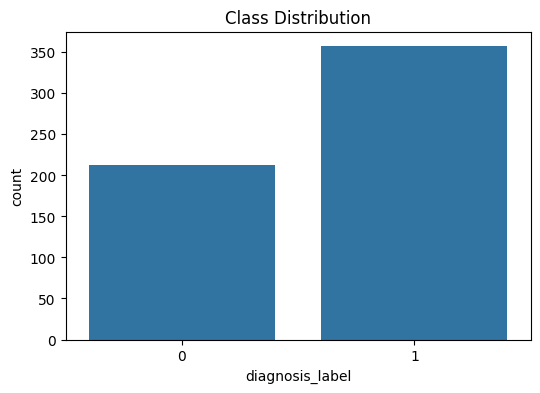

In [98]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis_label', data=df)
plt.title("Class Distribution")
plt.show()

### Class Distribution Analysis

The target variable is encoded as:
- **1 = Malignant (M):** 357 samples (62.7%)
- **0 = Benign (B):** 212 samples (37.3%)
The dataset has a moderate class imbalance. The Malignant class is approximately 1.68 times larger than the Benign class. This imbalance is not severe enough to require resampling techniques for this analysis, but it is accounted for by using `stratify=y` during train-test split and reporting per-class metrics in the classification report.

A stratified split ensures both train and test sets preserve this class ratio.


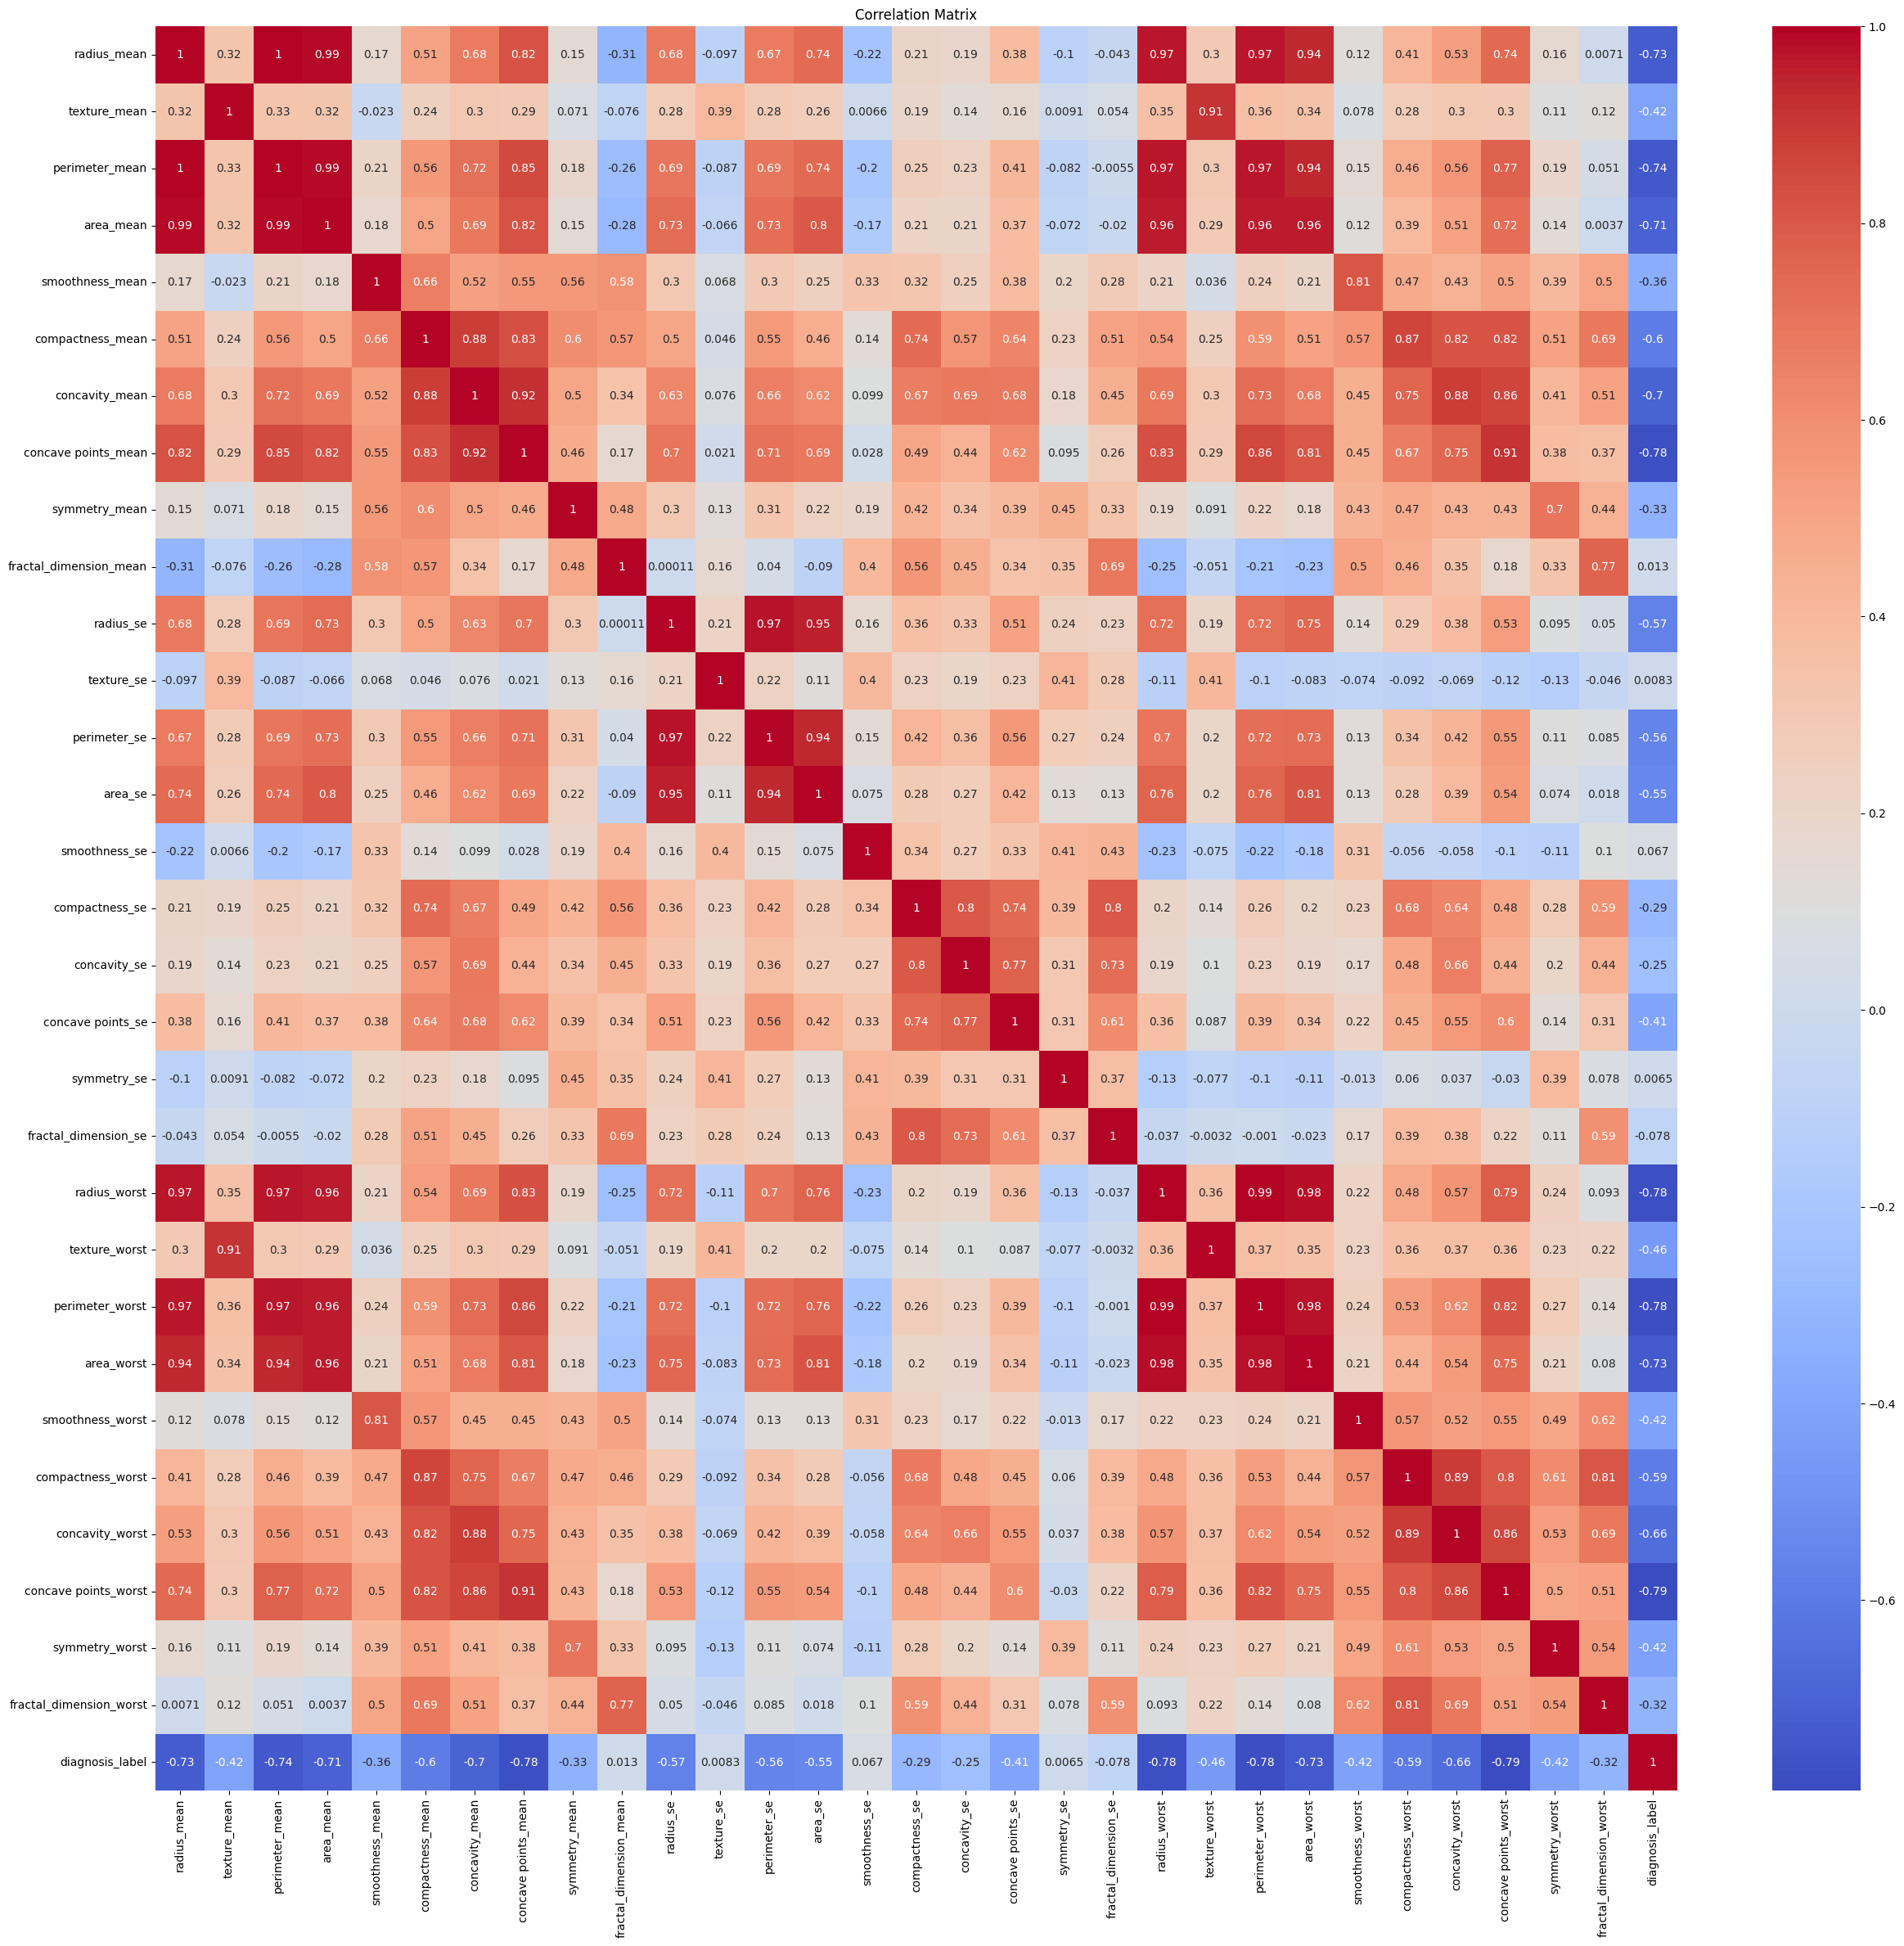

In [117]:
plt.figure(figsize=(30,28))
sns.heatmap(df.drop(['id', 'diagnosis'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

The correlation heatmap reveals strong multicollinearity clusters within the feature set:

- **radius_mean, perimeter_mean, and area_mean** are nearly perfectly correlated (r > 0.99) — these three features encode essentially the same information about tumor size
- **compactness_mean, concavity_mean, and concave_points_mean** form another highly correlated cluster (r > 0.88)
- The `_mean`, `_se` (standard error), and `_worst` groups of the same measurement type show high within-group correlation
This high multicollinearity motivates the application of **Principal Component Analysis (PCA)** later in the notebook to decorrelate features and reduce dimensionality without significant information loss.


## 5. Data Preprocessing

Preprocessing transforms raw data into a format suitable for machine learning algorithms. The following steps are applied:

1. **Feature-Target Separation:** The 30 numeric columns form the feature matrix `X`; `diagnosis_label` is the target vector `y`
2. **Train-Test Split:** 80/20 stratified split using `random_state=42` for reproducibility
3. **Feature Scaling:** `StandardScaler` is fit exclusively on the training set and applied to both train and test sets — this prevents data leakage and ensures the test set remains a true holdout
StandardScaler transforms each feature to zero mean and unit variance, which is essential for distance-based algorithms (SVM) and regularized models (Logistic Regression) to function correctly.


In [100]:
feature_names = df.drop(['id', 'diagnosis', 'diagnosis_label'], axis=1).columns
X = df[feature_names].values
y = df['diagnosis_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Baseline Model Training

Three classifiers are selected to represent different algorithmic families:

- **Logistic Regression** — a linear probabilistic classifier; interpretable and efficient
- **Random Forest** — an ensemble of decision trees; captures non-linear interactions and provides implicit feature importance
- **Support Vector Machine (SVM)** — a maximum-margin classifier; particularly effective in high-dimensional spaces
All three models are trained on the full 30-feature scaled dataset. This establishes a performance **baseline** against which dimensionality-reduced models will be compared.


In [101]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True)
}

baseline_results = {}

print("\n--- BASELINE RESULTS ---")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    baseline_results[name] = {
        'acc': acc,
        'auc': auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"{name} → Accuracy: {acc:.4f}, AUC: {auc:.4f}")


--- BASELINE RESULTS ---
Logistic Regression → Accuracy: 0.9825, AUC: 0.9954
Random Forest → Accuracy: 0.9474, AUC: 0.9932
SVM → Accuracy: 0.9825, AUC: 0.9950


### Baseline Results Interpretation

| Model               | Accuracy | AUC-ROC |
|---------------------|----------|---------|
| Logistic Regression | 98.25%   | 0.9954  |
| Random Forest       | 94.74%   | 0.9932  |
| SVM                 | 98.25%   | 0.9950  |

All three classifiers achieve strong performance on the full feature set. Notably:

- **Logistic Regression and SVM both achieve 98.25% accuracy** — indicating the classes are largely linearly separable in the standardized feature space
- **AUC values above 0.99** for all models indicate near-perfect class discrimination capability
- Random Forest performs slightly below the linear models on this dataset, which is consistent with the linear separability of the data
These results validate the quality of the dataset and preprocessing pipeline.


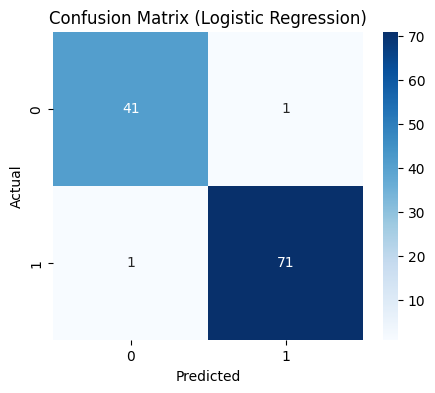

In [102]:
cm = confusion_matrix(y_test, baseline_results['Logistic Regression']['y_pred'])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Result — Logistic Regression

The confusion matrix for Logistic Regression on the test set (n=114) shows:
- **41 True Negatives** (Benign correctly identified)
- **71 True Positives** (Malignant correctly identified)
- **1 False Positive** (Benign misclassified as Malignant)
- **1 False Negative** (Malignant misclassified as Benign)
Only **2 total misclassifications** out of 114 samples. In a clinical context, the false negative (missed malignant tumor) is the more critical error — further threshold tuning or recall-focused optimization is discussed in the Future Improvements section.


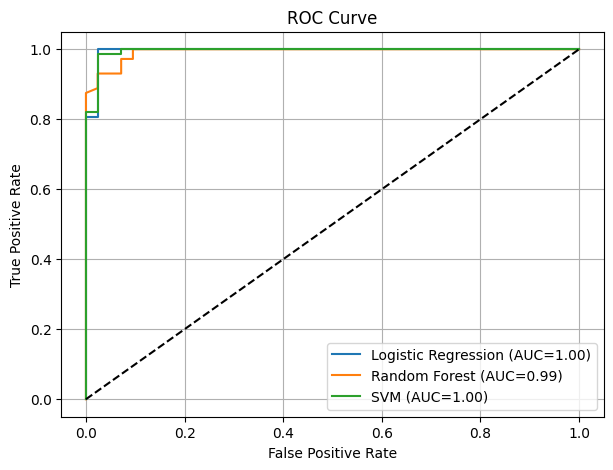

In [103]:
plt.figure(figsize=(7,5))

for name, res in baseline_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

### ROC Curve Analysis

The ROC curves for all three models approach the top-left corner of the plot, confirming exceptional discriminative performance:

- **Logistic Regression AUC = 1.00**
- **SVM AUC = 1.00**
- **Random Forest AUC = 0.99**
The near-perfect AUC scores indicate that at an appropriate threshold, these models can separate Malignant from Benign cases with almost no overlap in the predicted probability distributions.


## 7. Cross-Validation

A single train-test split can produce optimistic or pessimistic results depending on how data is partitioned. **5-fold stratified cross-validation** on the training set provides a more reliable estimate of generalization performance by evaluating each model on five different held-out subsets.

Cross-validation scores are reported as mean accuracy across all five folds.



In [104]:
print("\n--- CROSS VALIDATION ---")

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


--- CROSS VALIDATION ---
Logistic Regression CV Accuracy: 0.9802
Random Forest CV Accuracy: 0.9560
SVM CV Accuracy: 0.9714


### Cross-Validation Results

| Model               | CV Accuracy (5-Fold) |
|---------------------|----------------------|
| Logistic Regression | 98.02%               |
| Random Forest       | 95.60%               |
| SVM                 | 97.14%               |

Cross-validation accuracy is consistent with the test set accuracy, confirming that the models are **not overfitting** and that the strong performance observed on the holdout set generalizes across different data splits. Logistic Regression maintains its position as the top-performing model.

## 8. Dimensionality Reduction — Principal Component Analysis (PCA)

With 30 features — many of which are highly correlated — PCA offers a principled way to reduce the feature space while retaining the maximum amount of variance. PCA transforms the original features into a set of orthogonal (uncorrelated) components ordered by the amount of variance they explain.

**Why apply PCA here?**
- 30 features include significant redundancy (radius, perimeter, area are near-perfectly correlated)
- Fewer features reduce computational cost and can improve model interpretability
- PCA removes noise from less informative dimensions
PCA is fit exclusively on `X_train_scaled` to avoid any leakage of test set statistics into the transformation.


In [105]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

n_90 = np.argmax(cumulative_var >= 0.90) + 1

print("Components for 90% variance:", n_90)

Components for 90% variance: 7


### Variance Analysis

PCA on the 30-feature scaled dataset reveals that **7 principal components are sufficient to explain 90% of the total variance**. This represents a **76.67% reduction in dimensionality** (from 30 to 7 features).

The Scree Plot below visualizes the cumulative explained variance as a function of the number of components. The red dashed line marks the 90% variance threshold, and the green dashed line marks the 7-component cutoff.

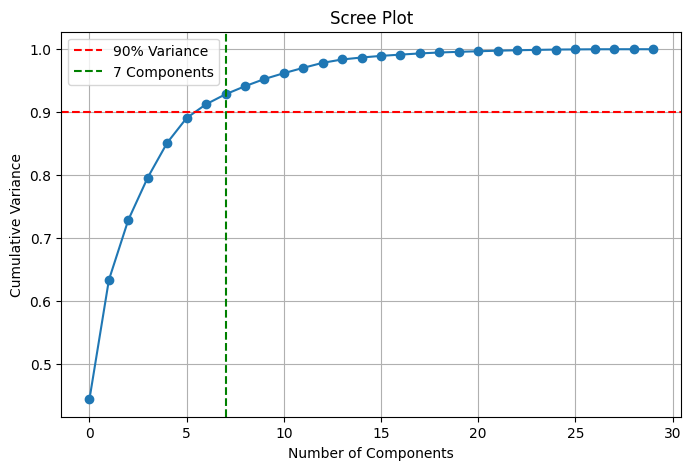

In [106]:
plt.figure(figsize=(8,5))

plt.plot(cumulative_var, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axvline(x=n_90, color='g', linestyle='--', label=f'{n_90} Components')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Scree Plot")
plt.legend()
plt.grid()
plt.show()

### Scree Plot Interpretation

The cumulative variance curve rises steeply for the first 5-7 components and then flattens into a plateau. This classic "elbow" pattern confirms that a small number of principal components capture the dominant structure of the data.

- **PC1 alone** captures approximately 44% of the variance
- **7 components** collectively capture 90%
- **Beyond 10 components**, each additional component contributes negligibly
This justifies reducing the feature space to 7 components for the PCA experiments below.



### Model Retraining on PCA-Reduced Features

All three baseline models are retrained on the 7-component PCA representation. This allows a direct comparison of accuracy and AUC before and after dimensionality reduction, quantifying the cost (or benefit) of compression.


In [107]:
original = 30
reduced = n_90

reduction = (1 - reduced/original) * 100
print(f"Feature reduction: {reduction:.2f}%")

Feature reduction: 76.67%


In [108]:
pca = PCA(n_components=n_90)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [109]:
pca_results = {}

print("\n--- PCA RESULTS ---")

for name, model in models.items():
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)
    y_proba = model.predict_proba(X_test_pca)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    pca_results[name] = {'acc': acc, 'auc': auc}

    print(f"{name} (PCA) → Accuracy: {acc:.4f}, AUC: {auc:.4f}")


--- PCA RESULTS ---
Logistic Regression (PCA) → Accuracy: 0.9474, AUC: 0.9937
Random Forest (PCA) → Accuracy: 0.9035, AUC: 0.9840
SVM (PCA) → Accuracy: 0.9561, AUC: 0.9947


### PCA Results Interpretation

| Model               | Accuracy (PCA) | AUC-ROC (PCA) |
|---------------------|----------------|---------------|
| Logistic Regression | 94.74%         | 0.9937        |
| Random Forest       | 90.35%         | 0.9840        |
| SVM                 | 95.61%         | 0.9947        |

The trade-off is clear: reducing from 30 to 7 features causes a **3-4% drop in accuracy** but:
- AUC remains above 0.984 for all models — discriminative power is largely preserved
- The SVM maintains the best accuracy in the PCA space (95.61%)
- This compression is highly valuable for deployment scenarios with strict latency or memory constraints


## 9. Dimensionality Reduction — Linear Discriminant Analysis (LDA)

Unlike PCA, which is an unsupervised method that maximizes variance, **LDA is a supervised dimensionality reduction technique** that maximizes class separability. LDA finds a linear projection that best separates the Malignant and Benign classes.

For a binary classification problem, LDA reduces the feature space to a single discriminant component. Logistic Regression is then applied to this 1-dimensional LDA projection.



In [110]:
lda = LDA()

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

lda_model = LogisticRegression(max_iter=1000)
lda_model.fit(X_train_lda, y_train)

y_pred_lda = lda_model.predict(X_test_lda)

lda_acc = accuracy_score(y_test, y_pred_lda)

print("\nLDA Accuracy:", lda_acc)


LDA Accuracy: 0.9736842105263158


### LDA Result

**LDA Accuracy: 97.37%**

A single LDA component achieves 97.37% accuracy — higher than all three PCA-reduced models and only marginally below the full-feature Logistic Regression (98.25%). This confirms that the two classes are highly linearly separable and that class-aware projections capture the most discriminative information efficiently.



## 10. Hyperparameter Tuning — GridSearchCV

Default hyperparameters are rarely optimal. **GridSearchCV** performs an exhaustive search over a predefined parameter grid, evaluating each combination through 5-fold cross-validation to identify the configuration that maximizes generalization accuracy.

For Logistic Regression, the key hyperparameters are:
- **C** (regularization strength): smaller values apply stronger regularization
- **solver**: the optimization algorithm used to minimize the loss function
The grid searches over `C ∈ {0.01, 0.1, 1, 10}` and `solver ∈ {'liblinear', 'lbfgs'}`.



In [111]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best CV Score: 0.9802197802197803


### Hyperparameter Tuning Results

**Best Parameters:** `C = 0.1`, `solver = 'lbfgs'`  
**Best CV Score:** 98.02%

The optimal regularization strength of `C = 0.1` applies moderate L2 regularization, slightly stronger than the default (`C = 1`). This indicates that the model benefits from constraining coefficient magnitudes, which is expected given the high feature multicollinearity in the original space.

## 11. Final Model Comparison

This section consolidates all experimental results into a single comparison table — baseline (full features) vs. PCA-reduced — across all three classifiers. This is the primary deliverable for understanding the accuracy-dimensionality trade-off in this study.



In [112]:
results = []

# Before PCA
for name, res in baseline_results.items():
    results.append([name, "Before PCA", res['acc'], res['auc']])

    # After PCA
    for name, res in pca_results.items():
        results.append([name, "After PCA", res['acc'], res['auc']])

        results_df = pd.DataFrame(results, columns=["Model", "Stage", "Accuracy", "AUC"])

        print("\nFinal Comparison:\n")
        print(results_df)


Final Comparison:

                 Model       Stage  Accuracy       AUC
0  Logistic Regression  Before PCA  0.982456  0.995370
1  Logistic Regression   After PCA  0.947368  0.993717

Final Comparison:

                 Model       Stage  Accuracy       AUC
0  Logistic Regression  Before PCA  0.982456  0.995370
1  Logistic Regression   After PCA  0.947368  0.993717
2        Random Forest   After PCA  0.903509  0.983962

Final Comparison:

                 Model       Stage  Accuracy       AUC
0  Logistic Regression  Before PCA  0.982456  0.995370
1  Logistic Regression   After PCA  0.947368  0.993717
2        Random Forest   After PCA  0.903509  0.983962
3                  SVM   After PCA  0.956140  0.994709

Final Comparison:

                 Model       Stage  Accuracy       AUC
0  Logistic Regression  Before PCA  0.982456  0.995370
1  Logistic Regression   After PCA  0.947368  0.993717
2        Random Forest   After PCA  0.903509  0.983962
3                  SVM   After PCA  0.95

### Summary of Before vs. After PCA

| Model               | Stage       | Accuracy | AUC    |
|---------------------|-------------|----------|--------|
| Logistic Regression | Before PCA  | 98.25%   | 0.9954 |
| Logistic Regression | After PCA   | 94.74%   | 0.9937 |
| Random Forest       | Before PCA  | 94.74%   | 0.9932 |
| Random Forest       | After PCA   | 90.35%   | 0.9840 |
| SVM                 | Before PCA  | 98.25%   | 0.9950 |
| SVM                 | After PCA   | 95.61%   | 0.9947 |

**Key takeaway:** PCA compression (76.67% feature reduction) costs roughly 3-4% in accuracy but preserves AUC above 0.98 for all models. For production deployment under resource constraints, the SVM with 7 PCA components (95.61% accuracy, 0.9947 AUC) offers the best post-compression performance.

## 12. PCA 2D Visualization

To gain geometric intuition about class separability, the training data is projected onto the first two principal components (PC1 and PC2) and plotted as a scatter plot. Each point represents one patient record, colored by diagnosis class.

This visualization answers: "Are the two classes visually distinguishable in the principal component space?"


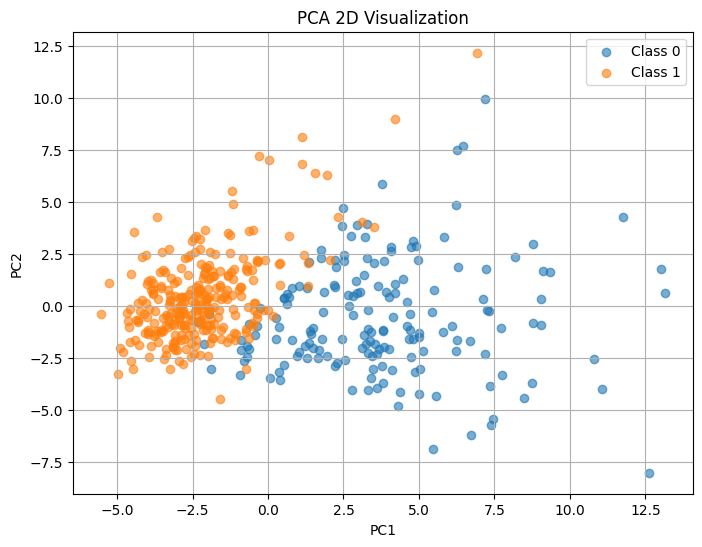

In [113]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

for label, color in zip([0,1], ['red','green']):
    plt.scatter(
        X_2d[y_train==label, 0],
        X_2d[y_train==label, 1],
        label=f"Class {label}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Visualization")
plt.legend()
plt.grid()
plt.show()

### PCA 2D Visualization Interpretation

The scatter plot confirms that **Class 0 (Benign, blue) and Class 1 (Malignant, orange) exhibit meaningful separation along PC1**. The Benign class tends to cluster at higher positive PC1 values, while the Malignant class clusters at lower PC1 values with more compact grouping.

There is some overlap in the central region, which accounts for the ~5% of test cases that are misclassified. This overlap is expected — it reflects genuine biological similarity between borderline cases.

The clear two-cluster structure in 2D validates the high model performance observed and explains why even simple linear classifiers like Logistic Regression perform so well on this dataset.


### Accuracy vs. Number of PCA Components

The following experiment quantifies how model accuracy changes as the number of PCA components increases from 2 to 30. Logistic Regression is retrained for each component count on both the PCA-transformed training and test sets.

This analysis identifies the minimum number of components needed to achieve near-maximum accuracy — an important consideration for model compression.


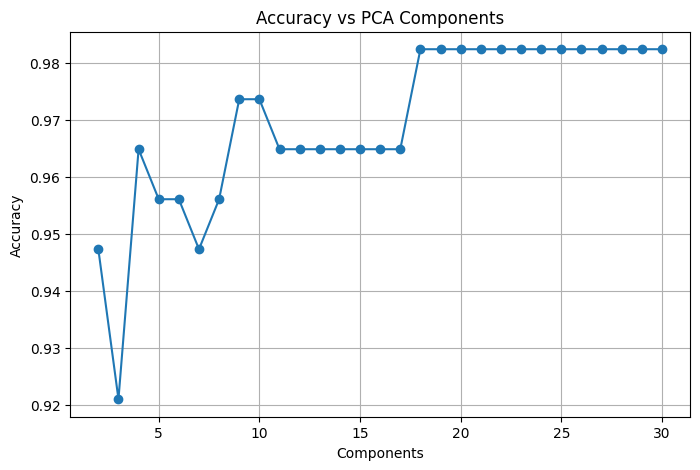

In [114]:
comp_range = list(range(2, 31))
lr_acc = []

for n in comp_range:
    pca_temp = PCA(n_components=n)
    X_tr = pca_temp.fit_transform(X_train_scaled)
    X_te = pca_temp.transform(X_test_scaled)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_train)

    lr_acc.append(accuracy_score(y_test, model.predict(X_te)))

plt.figure(figsize=(8,5))
plt.plot(comp_range, lr_acc, marker='o')

plt.xlabel("Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components")
plt.grid()

plt.show()

### Component Sweep Interpretation

The accuracy curve exhibits the following behavior:
- With 2-4 components, accuracy fluctuates between 92-97% as the model captures the primary axes of variation
- A notable dip occurs around 3-4 components, then recovers — reflecting sensitivity to specific principal components at low dimensionality
- Accuracy stabilizes above 98% once approximately **18+ components** are included
- The plateau confirms that components beyond ~18 contribute negligible discriminative information
For practical purposes, **7 components (90% variance threshold) represent a reasonable operating point** — balancing compression with minimal accuracy loss.



## 13. Classification Report — Best Model

The detailed classification report for the best-performing model (Logistic Regression, full features) provides per-class precision, recall, and F1-score. These metrics are more informative than overall accuracy in a medical context where the cost of different error types is asymmetric.

In [115]:
print("\n--- CLASSIFICATION REPORT ---")

print(classification_report(
    y_test,
        baseline_results['Logistic Regression']['y_pred']
        ))


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Classification Report Interpretation

| Class     | Precision | Recall | F1-Score |
|-----------|-----------|--------|----------|
| 0 (Benign)    | 0.98  | 0.98   | 0.98     |
| 1 (Malignant) | 0.99  | 0.99   | 0.99     |

**Key observations:**

- **Precision for Malignant class = 0.99** — of all patients predicted as malignant, 99% truly have malignant tumors (very few false alarms)
- **Recall for Malignant class = 0.99** — of all actual malignant cases, 99% are correctly identified (very few missed diagnoses)
- **F1-score = 0.99** for the Malignant class confirms balanced precision and recall
In a clinical screening context, **recall (sensitivity) for the Malignant class is the most critical metric** — a missed malignant diagnosis has far greater consequences than a false positive. The 99% recall for Class 1 is clinically meaningful.

The macro-average F1-score of 0.98 across both classes confirms the model performs consistently regardless of class.

## 14. Conclusions and Summary

This project demonstrated a complete machine learning pipeline for breast cancer classification, yielding the following findings:

**Modeling Conclusions:**
- Logistic Regression achieves the highest baseline accuracy (98.25%) and AUC (0.9954) on 30 standardized features — the dataset is largely linearly separable
- 5-fold cross-validation confirms robust generalization without overfitting
- PCA reduces dimensionality by 76.67% (30 to 7 components) with only 3-4% accuracy loss — a worthwhile trade-off for deployment scenarios
- LDA achieves 97.37% accuracy using a single discriminant component — demonstrating the strong class separability from a supervised projection perspective
- GridSearchCV identifies moderate regularization (C=0.1) as optimal for Logistic Regression
**Clinical Relevance:**
- With only 2 misclassifications out of 114 test samples, the model demonstrates the potential of ML as a diagnostic assistance tool
- The 99% recall for the Malignant class is clinically significant — the model rarely misses a true malignant case
- Any deployment in a real clinical setting would require prospective validation, regulatory approval, and physician oversight.